# Обедающие философы: параметрический эксперимент

Исследуется влияние числа философов и интенсивности захвата левой вилки на
вероятность deadlock, производительность и равномерность доступа к ресурсам.

In [1]:
using DrWatson
@quickactivate "project"
ENV["GKSwstype"] = "100"
using CSV, DataFrames, Plots, Random, Statistics
include(srcdir("dining_philosophers.jl"))
using .DiningPhilosophers

## Параметры серии

In [2]:
const TMAX = 50.0
const REPLICATIONS = 20
const IMAGE_DIR = projectdir("..", "image")
const DATA_DIR = datadir("02_parameter_scan")
mkpath(IMAGE_DIR)
mkpath(DATA_DIR)

"/workspace/labs/lab05/project/data/02_parameter_scan"

## Выполнение 960 независимых траекторий
Для каждого повтора сохраняются исход, время остановки и показатели питания.

In [3]:
rows = NamedTuple[]
for N in 3:8, left_rate in (1.0, 1.5, 2.0, 3.0), replication in 1:REPLICATIONS
    rates = default_rates(N; left_rate, right_rate=1.0, release_rate=1.4)
    for (variant, builder) in (("Классическая", build_classical_network),
            ("С арбитром", build_arbiter_network))
        net, initial = builder(N)
        seed = 100_000N + 1_000round(Int, 10left_rate) + replication +
            (variant == "С арбитром" ? 500 : 0)
        result = simulate_stochastic(net, initial, TMAX;
            rates, rng=MersenneTwister(seed))
        push!(rows, (
            philosophers=N,
            left_rate=left_rate,
            replication=replication,
            variant=variant,
            deadlock=result.deadlock,
            stop_time=result.stop_time,
            events=result.events,
            meals=sum(result.meal_counts),
            fairness=jain_fairness(result.meal_counts),
        ))
    end
end

replications = DataFrame(rows)
CSV.write(joinpath(DATA_DIR, "replications.csv"), replications)

"/workspace/labs/lab05/project/data/02_parameter_scan/replications.csv"

## Агрегирование по параметрам
Частота deadlock вычисляется по двадцати повторам одной комбинации.

In [4]:
summary = combine(groupby(replications, [:philosophers, :left_rate, :variant]),
    :deadlock => mean => :deadlock_probability,
    :stop_time => mean => :mean_stop_time,
    :events => mean => :mean_events,
    :meals => mean => :mean_meals,
    :fairness => mean => :mean_fairness)
CSV.write(joinpath(DATA_DIR, "summary.csv"), summary)

println("=== Параметрический эксперимент ===")
println("Число прогонов: $(nrow(replications))")
selected = filter(row -> row.left_rate == 2.0, summary)
show(select(selected, :philosophers, :variant, :deadlock_probability,
    :mean_meals, :mean_fairness); allrows=true, allcols=true)
println()

=== Параметрический эксперимент ===
Число прогонов: 960
12×5 DataFrame
 Row │ philosophers  variant       deadlock_probability  mean_meals  mean_fairness 
     │ Int64         String        Float64               Float64     Float64       
─────┼─────────────────────────────────────────────────────────────────────────────
   1 │            3  Классическая                   1.0        1.0        0.274444
   2 │            3  С арбитром                     0.0       29.1        0.944186
   3 │            4  Классическая                   1.0        1.35       0.320833
   4 │            4  С арбитром                     0.0       29.7        0.934264
   5 │            5  Классическая                   1.0        1.6        0.23626
   6 │            5  С арбитром                     0.0       29.05       0.90706
   7 │            6  Классическая                   1.0        1.2        0.181481
   8 │            6  С арбитром                     0.0       30.8        0.894038
   9 │         

## Наблюдаемая доля блокировок

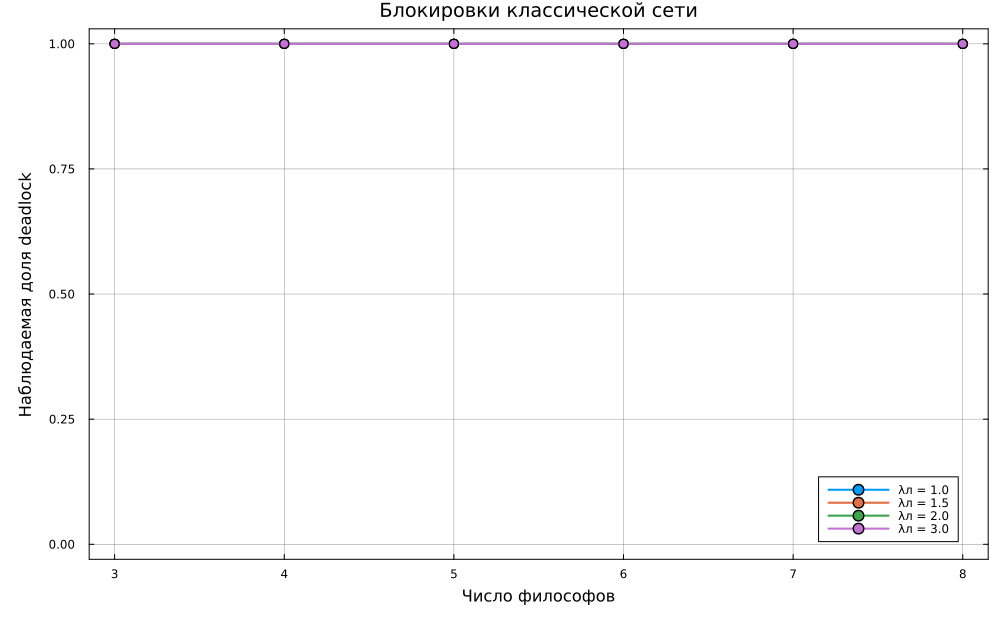

In [5]:
default(fontfamily="DejaVu Sans", linewidth=2.1, markersize=5,
    framestyle=:box, gridalpha=0.22, legendfontsize=8, guidefontsize=11,
    titlefontsize=13, left_margin=7Plots.mm, bottom_margin=5Plots.mm)

classic = filter(row -> row.variant == "Классическая", summary)
p5 = plot(; xlabel="Число философов", ylabel="Наблюдаемая доля deadlock",
    title="Блокировки классической сети", ylims=(-0.03, 1.03), size=(1000, 620))
for rate in sort(unique(classic.left_rate))
    subset = filter(row -> row.left_rate == rate, classic)
    sort!(subset, :philosophers)
    plot!(p5, subset.philosophers, subset.deadlock_probability;
        marker=:circle, label="λл = $rate")
end
savefig(p5, joinpath(IMAGE_DIR, "06-plot.png"))
display(p5)

## Производительность и равномерность

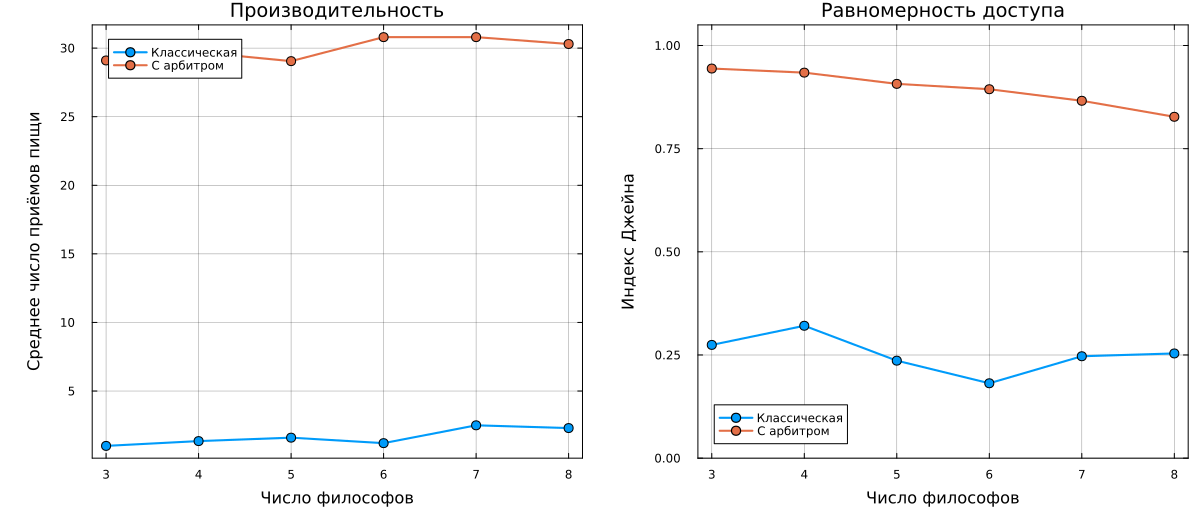

In [6]:
rate_two = filter(row -> row.left_rate == 2.0, summary)
p6a = plot(; xlabel="Число философов", ylabel="Среднее число приёмов пищи",
    title="Производительность")
p6b = plot(; xlabel="Число философов", ylabel="Индекс Джейна",
    title="Равномерность доступа", ylims=(0, 1.05))
for variant in ("Классическая", "С арбитром")
    subset = filter(row -> row.variant == variant, rate_two)
    sort!(subset, :philosophers)
    plot!(p6a, subset.philosophers, subset.mean_meals;
        marker=:circle, label=variant)
    plot!(p6b, subset.philosophers, subset.mean_fairness;
        marker=:circle, label=variant)
end
p6 = plot(p6a, p6b; layout=(1, 2), size=(1200, 520),
    left_margin=11Plots.mm, bottom_margin=7Plots.mm)
savefig(p6, joinpath(IMAGE_DIR, "07-plot.png"))
display(p6)

Серия повторных прогонов отделяет устойчивый эффект структуры сети от
случайности отдельных траекторий. Для сети с арбитром наблюдаемая доля глобальных
блокировок равна нулю во всей исследованной области параметров.